## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

In [74]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(nr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=7):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[24:24+nz,24:24+nx,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWI',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

## Homo model

In [30]:
ε_r=12; μ_r=1; c=299 #m/μs

v = c/np.sqrt(ε_r*μ_r)
print('v =',v) #86 m/μs

fpeak = 400 #MHz

λmin = v/fpeak/2
print('λmin =',λmin) #0.1079 m

h=0.02 #m

nz=241; nx=241; print(f'length = {(nz-1)*h} m')
nzsnap=289; nxsnap=289; nsnap=51

dt_CFL = 0.6*h/v
print('dt_CFL =',dt_CFL) #μs
dt = 0.000139 #μs. SU_DT = 139 ps

nt = 1000 #T=0.139 μs
t=np.arange(0,nt*dt,dt)

v = 86.31386524384905
λmin = 0.10789233155481132
length = 4.8 m
dt_CFL = 0.000139027489570746


In [26]:
eps_r = ε_r*np.ones((nz,nx))
eps_r.T.astype('float32').tofile('model')

In [37]:
%%writefile setup

MODEL_SIZE              '241   241   1'
MODEL_SPACING           '0.02  0.02  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'eps_r'

ACQUI_GEOMETRY          spread
FS                      '1.6  1.6  0'
FR                      '1.6  1.6  0'
DR                      '  0    0  0'
NR                       1

IF_HICKS                 F

SCOMP                    Ey
RCOMP                    Ey

NT                       1000
DT                       0.000139
WAVELET_TYPE             ricker
FPEAK                    400

SNAPSHOT                'Hx Hz Ey'

IF_USE_CHECKPOINT        F

Overwriting setup


### run

In [32]:
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 2181064 Jun 19 12:59 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: f9d3f55
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 12:59:58
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal

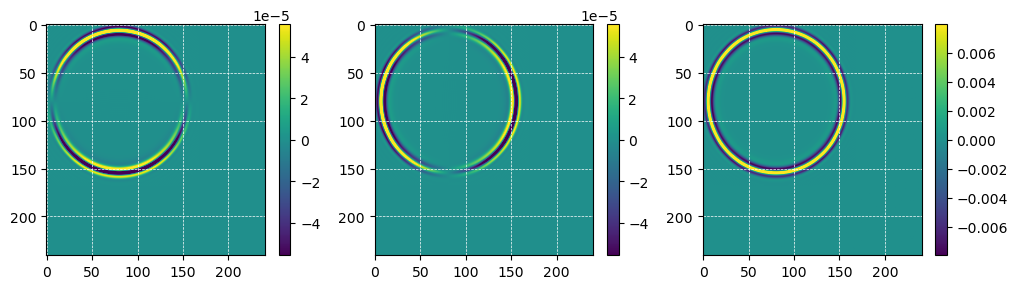

In [35]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results/snap_fld_u%Ey'),perc=98)

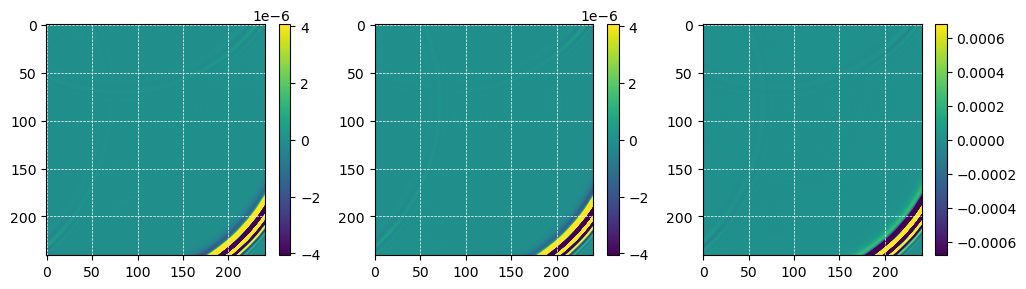

In [36]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results/snap_fld_u%Hx',i=17),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results/snap_fld_u%Hz',i=17),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results/snap_fld_u%Ey',i=17),perc=98)

## Herten model line0
Roncoroni et al., 2025

nz,nx = 278, 640  
dz,dx = 27, 25 (mm)

In [53]:
!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/eps/line0_eps_25mm.sgy    | suflip flip=3 | sustrip > eps_r
!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/mu/line0_mu_25mm.sgy      | suflip flip=3 | sustrip > mu_r
!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/sigma/line0_sigm_25mm.sgy | suflip flip=3 | sustrip > sgma_r
#!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/sigma/line3_sigm_25mm.sgy | suflip flip=3 | sustrip > sgma_r

3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00316574 s, 1.0 MB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00342729 s, 934 kB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00320826 s, 997 kB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278


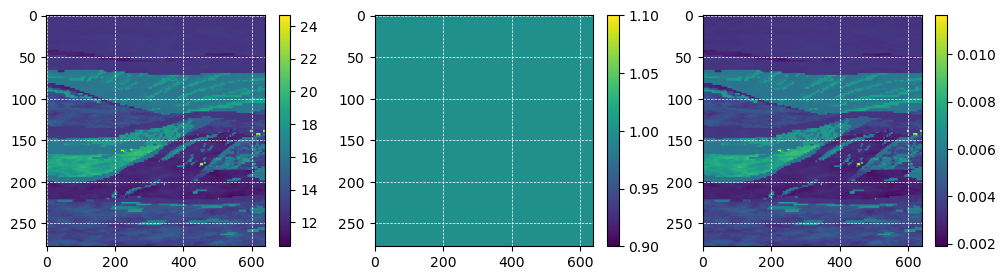

In [55]:
ε_r=read('eps_r' ,(640,278))
μ_r=read('mu_r'  ,(640,278))
σ_r=read('sgma_r',(640,278))

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(ε_r)
plt.subplot(1,3,2); imshow(μ_r)
plt.subplot(1,3,3); imshow(σ_r)

In [44]:
v = c/np.sqrt(ε_r*μ_r)
print('vmin,vmax =',v.min(),v.max())

vmin,vmax = 60.230625 92.11606


In [76]:
fpeak = 50 #MHz

λmin = v.min()/fpeak/2
print('λmin, λmin/5 =',λmin,λmin/5)

h=0.12 #m

nz=int(278*0.027/h)
nx=int(640*0.025/h)
print(f'nz,nx = {nz,nx}')
nzsnap=nz+48
nxsnap=nx+48
nsnap=50
print(f'nzsnap,nxsnap = {nzsnap,nxsnap}')

dt_CFL = 0.6*h/v.max()
print('dt_CFL =',dt_CFL) #μs
dt = 0.000781 #μs. SU_DT = 781 ps

T=0.3 #μs
nt = int(T/dt)
print('nt = ',nt)
# t=np.arange(0,nt*dt,dt)

λmin, λmin/5 = 0.6023062515258789 0.12046125030517578
nz,nx = (62, 133)
nzsnap,nxsnap = (110, 181)
dt_CFL = 0.0007816226756765621
nt =  384


In [63]:
cmd=f'unisam2 < eps_r  > eps_r.{h}   nx1=278 nx2=640 dx1=0.027 dx2=0.025  n1={nz} n2={nx} d1={h} d2={h}'
!$cmd
cmd=f'unisam2 < mu_r   > mu_r.{h}    nx1=278 nx2=640 dx1=0.027 dx2=0.025  n1={nz} n2={nx} d1={h} d2={h}'
!$cmd
cmd=f'unisam2 < sgma_r > sgma_r.{h}  nx1=278 nx2=640 dx1=0.027 dx2=0.025  n1={nz} n2={nx} d1={h} d2={h}'
!$cmd

!cat eps_r.$h mu_r.$h sgma_r.$h > model

In [72]:
%%writefile setup

MODEL_SIZE              '62    133   1'
MODEL_SPACING           '0.12  0.12  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'eps_r mu_r' #sgma_r'

ACQUI_GEOMETRY          spread
FS                      '  0    6  0'
FR                      '  0    0  0'
DR                      '  0  0.1  0'
NR                       1

IF_HICKS                 F

SCOMP                    Ey
RCOMP                    Ey

FPEAK                    50

NT                       390
DT                       0.000781
WAVELET_TYPE             ricker

SNAPSHOT                'Hx Hz Ey'

IF_USE_CHECKPOINT        F

Overwriting setup


### run

In [73]:
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 2181696 Jun 19 13:50 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: f9d3f55
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 13:52:43
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal

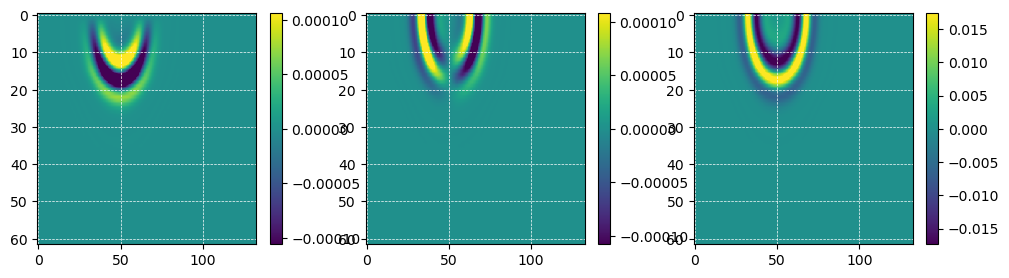

In [78]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results/snap_fld_u%Hx',(nsnap,nxsnap,nzsnap)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results/snap_fld_u%Hz',(nsnap,nxsnap,nzsnap)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results/snap_fld_u%Ey',(nsnap,nxsnap,nzsnap)),perc=98)

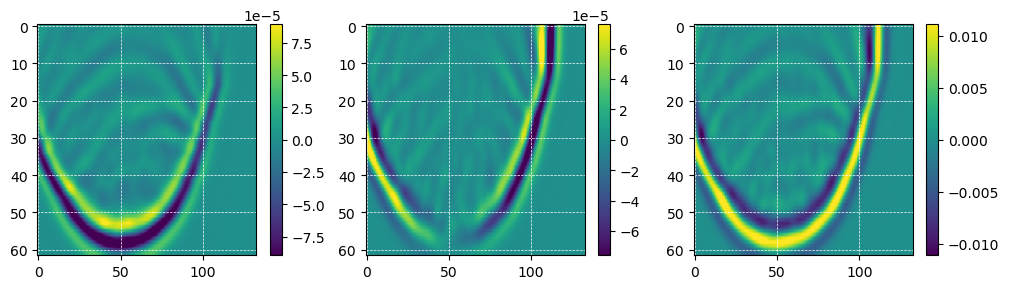

In [79]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results/snap_fld_u%Hx',(nsnap,nxsnap,nzsnap),i=17),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results/snap_fld_u%Hz',(nsnap,nxsnap,nzsnap),i=17),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results/snap_fld_u%Ey',(nsnap,nxsnap,nzsnap),i=17),perc=98)